# AI-ML Assignment – 7
## Customer Segmentation using K-Means Clustering and PCA

### Objective
The objective of this assignment is to segment mall customers into meaningful groups based on their demographic and spending characteristics using K-Means Clustering. Principal Component Analysis (PCA) is then applied to reduce the feature dimensions and visualize the customer clusters in two dimensions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("Mall_Customers.csv")

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
Index(['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')

Categorical Features:
Index(['Gender'], dtype='object')


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## Task 2: Data Preprocessing

In [7]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [8]:
df = df.drop(columns=['CustomerID'])

In [9]:
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

X = df[features]

The Gender column is a categorical variable. Since the objective is to segment customers based on their age, annual income, and spending behavior, the clustering model uses the three numerical features. Therefore, categorical encoding is not required for the features used by the K-Means model.

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

X_scaled_df.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


## Task 3: Model Development

In [12]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

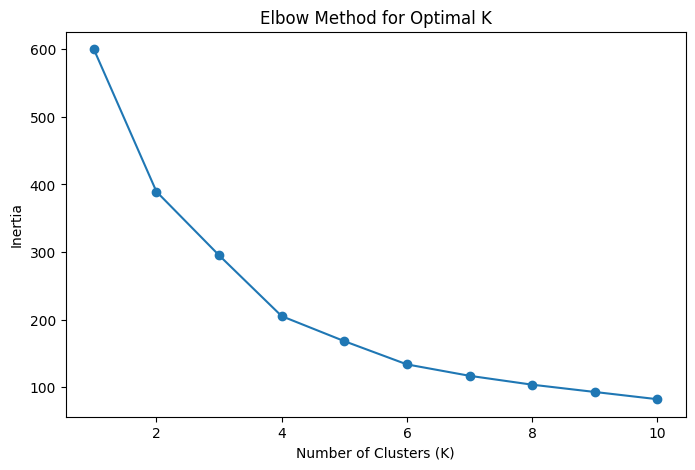

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

In [14]:
optimal_k = 5

In [15]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

cluster_labels = kmeans.fit_predict(X_scaled)

In [16]:
df['Cluster'] = cluster_labels

In [17]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,Male,19,15,39,1
1,Male,21,15,81,1
2,Female,20,16,6,0
3,Female,23,16,77,1
4,Female,31,17,40,1


In [18]:
df['Cluster'].value_counts().sort_index()

,count
Cluster,
0,20
1,54
2,40
3,39
4,47


In [19]:
cluster_summary = df.groupby('Cluster')[features].mean()

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,46.250000,26.750000,18.350000
1,25.185185,41.092593,62.240741
2,32.875000,86.100000,81.525000
3,39.871795,86.102564,19.358974
4,55.638298,54.382979,48.851064


### Principal Component Analysis (PCA)

In [20]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [21]:
pca_df = pd.DataFrame(
    X_pca,
    columns=['Principal Component 1', 'Principal Component 2']
)

pca_df['Cluster'] = cluster_labels

pca_df.head()

,Principal Component 1,Principal Component 2,Cluster
0,-0.615720,-1.763481,1
1,-1.665793,-1.820747,1
2,0.337862,-1.674799,0
3,-1.456573,-1.772430,1
4,-0.038465,-1.662740,1


In [22]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Explained Variance:", pca.explained_variance_ratio_.sum())

Explained Variance Ratio: [0.44266167 0.33308378]
Total Explained Variance: 0.7757454566976747


## Task 4: Visualization and Evaluation

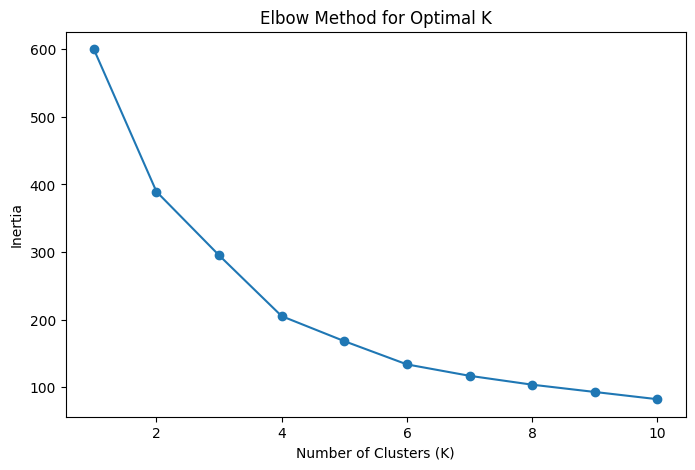

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

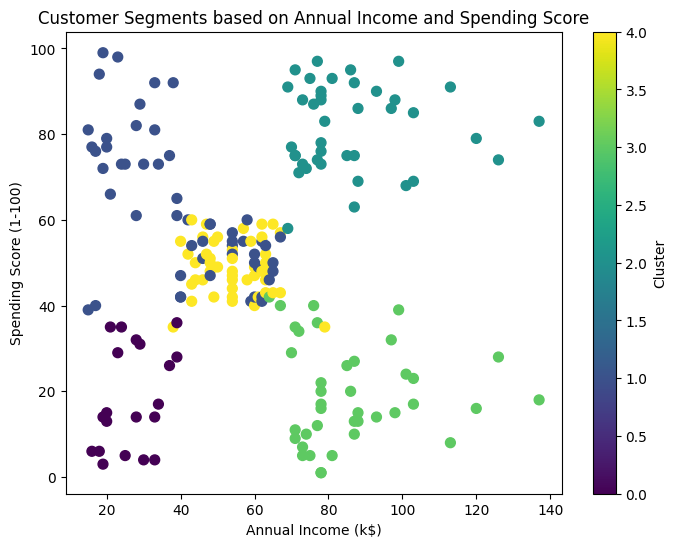

In [24]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    cmap='viridis',
    s=50
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments based on Annual Income and Spending Score')
plt.colorbar(label='Cluster')
plt.show()

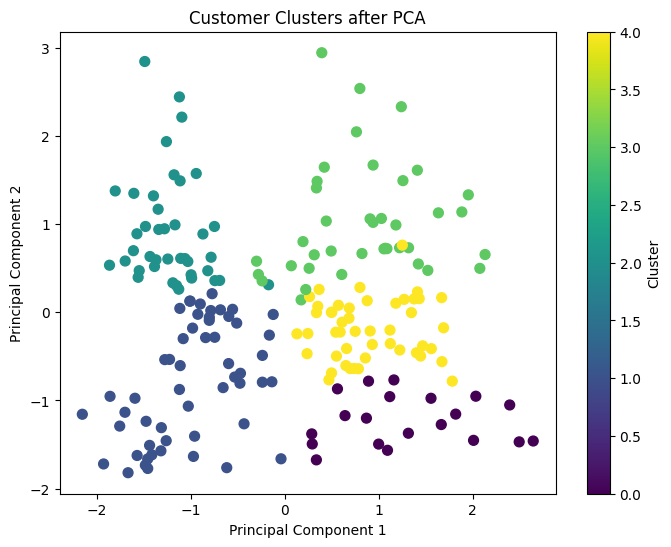

In [25]:
plt.figure(figsize=(8, 6))

plt.scatter(
    pca_df['Principal Component 1'],
    pca_df['Principal Component 2'],
    c=pca_df['Cluster'],
    cmap='viridis',
    s=50
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Customer Clusters after PCA')
plt.colorbar(label='Cluster')
plt.show()

### Observations

1. The Elbow Method indicates that the optimal number of clusters is K = 5, as the reduction in inertia becomes less significant after this point.

2. K-Means clustering divides customers into distinct groups based on their age, annual income, and spending score, allowing customers with similar characteristics to be grouped together.

3. PCA reduces the three-dimensional feature space into two principal components, making it easier to visualize the customer clusters while preserving a significant amount of the variation in the data.

4. The identified clusters represent different customer profiles, such as high-income high-spending customers, high-income low-spending customers, and customers with lower income and different spending behaviors. These groups can be targeted with different marketing strategies.

## Task 5: Conclusion

This assignment successfully segmented mall customers using K-Means Clustering based on age, annual income, and spending score. The Elbow Method was used to determine an appropriate number of clusters, after which customers were assigned to different groups according to their similarities. PCA was then applied to reduce the feature space to two principal components, making the clusters easier to visualize. Customer segmentation can help businesses develop targeted marketing campaigns, personalize offers, identify high-value customers, and improve customer retention strategies. However, one limitation of K-Means is that the algorithm requires the number of clusters to be specified in advance and may be sensitive to the initial placement of centroids. PCA is advantageous because it reduces dimensionality while retaining important information, making complex datasets easier to analyze and visualize.
